# Part 1: Getting started

In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

2026-03-16 16:08:15.785648: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Fetch the jet tagging dataset from Open ML

In [2]:
data = fetch_openml('hls4ml_lhc_jets_hlf')
X, y = data['data'], data['target']

/home/ubuntu/anaconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


### Let's print some information about the dataset
Print the feature names and the dataset shape

In [3]:
print(data['feature_names'])
print(X.shape, y.shape)
print(X[:5])
print(y[:5])

['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']
(830000, 16) (830000,)
      zlogz  c1_b0_mmdt  c1_b1_mmdt  c1_b2_mmdt  c2_b1_mmdt  c2_b2_mmdt  \
0 -2.935125    0.383155    0.005126    0.000084    0.009070    0.000179   
1 -1.927335    0.270699    0.001585    0.000011    0.003232    0.000029   
2 -3.112147    0.458171    0.097914    0.028588    0.124278    0.038487   
3 -2.666515    0.437068    0.049122    0.007978    0.047477    0.004802   
4 -2.484843    0.428981    0.041786    0.006110    0.023066    0.001123   

   d2_b1_mmdt  d2_b2_mmdt  d2_a1_b1_mmdt  d2_a1_b2_mmdt  m2_b1_mmdt  \
0    1.769445    2.123898       1.769445       0.308185    0.135687   
1    2.038834    2.563099       2.038834       0.211886    0.063729   
2    1.269254    1.346238       1.269254       0.246488    0.115636   
3    0.966505  

As you saw above, the `y` target is an array of strings, e.g. \['g', 'w',...\] etc.
We need to make this a "One Hot" encoding for the training.
Then, split the dataset into training and validation sets

In [4]:
le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y, 5)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y[:5])

[[1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]]


In [5]:
scaler = StandardScaler()
X_train_val = scaler.fit_transform(X_train_val)
X_test = scaler.transform(X_test)

In [6]:
np.save('X_train_val.npy', X_train_val)
np.save('X_test.npy', X_test)
np.save('y_train_val.npy', y_train_val)
np.save('y_test.npy', y_test)
np.save('classes.npy', le.classes_)

## Now construct a model
We'll use 3 hidden layers with 64, then 32, then 32 neurons. Each layer will use `relu` activation.
Add an output layer with 5 neurons (one for each class), then finish with Softmax activation.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from callbacks import all_callbacks

In [8]:
model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

## Train the model
We'll use Adam optimizer with categorical crossentropy loss.
The callbacks will decay the learning rate and save the model into a directory 'model_1'
The model isn't very complex, so this should just take a few minutes even on the CPU.
If you've restarted the notebook kernel after training once, set `train = False` to load the trained model.

In [9]:
train = True
if train:
    adam = Adam(lr=0.0001)
    model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])
    callbacks = all_callbacks(
        stop_patience=1000,
        lr_factor=0.5,
        lr_patience=10,
        lr_epsilon=0.000001,
        lr_cooldown=2,
        lr_minimum=0.0000001,
        outputDir='model_1',
    )
    model.fit(
        X_train_val,
        y_train_val,
        batch_size=1024,
        epochs=10,
        validation_split=0.25,
        shuffle=True,
        callbacks=callbacks.callbacks,
    )
else:
    from tensorflow.keras.models import load_model

    model = load_model('model_1/KERAS_check_best_model.h5')

Epoch 1/10
484/487 [============================>.] - ETA: 0s - loss: 0.9589 - accuracy: 0.6831
***callbacks***
saving losses to model_1/losses.log

Epoch 1: val_loss improved from inf to 0.82902, saving model to model_1/KERAS_check_best_model.h5

Epoch 1: val_loss improved from inf to 0.82902, saving model to model_1/KERAS_check_best_model_weights.h5

Epoch 1: saving model to model_1/KERAS_check_model_last.h5

Epoch 1: saving model to model_1/KERAS_check_model_last_weights.h5

***callbacks end***

487/487 [==============================] - 2s 3ms/step - loss: 0.9581 - accuracy: 0.6833 - val_loss: 0.8290 - val_accuracy: 0.7338 - lr: 0.0010
Epoch 2/10
 35/487 [=>............................] - ETA: 1s - loss: 0.8157 - accuracy: 0.7363

/home/ubuntu/anaconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


481/487 [============================>.] - ETA: 0s - loss: 0.8014 - accuracy: 0.7405
***callbacks***
saving losses to model_1/losses.log

Epoch 2: val_loss improved from 0.82902 to 0.78907, saving model to model_1/KERAS_check_best_model.h5

Epoch 2: val_loss improved from 0.82902 to 0.78907, saving model to model_1/KERAS_check_best_model_weights.h5

Epoch 2: saving model to model_1/KERAS_check_model_last.h5

Epoch 2: saving model to model_1/KERAS_check_model_last_weights.h5

***callbacks end***

487/487 [==============================] - 2s 3ms/step - loss: 0.8012 - accuracy: 0.7405 - val_loss: 0.7891 - val_accuracy: 0.7440 - lr: 0.0010
Epoch 3/10
473/487 [============================>.] - ETA: 0s - loss: 0.7735 - accuracy: 0.7475
***callbacks***
saving losses to model_1/losses.log

Epoch 3: val_loss improved from 0.78907 to 0.77153, saving model to model_1/KERAS_check_best_model.h5

Epoch 3: val_loss improved from 0.78907 to 0.77153, saving model to model_1/KERAS_check_best_model_weig

## Check performance
Check the accuracy and make a ROC curve

5188/5188 [==============================] - 4s 787us/step
Accuracy: 0.7581566265060241


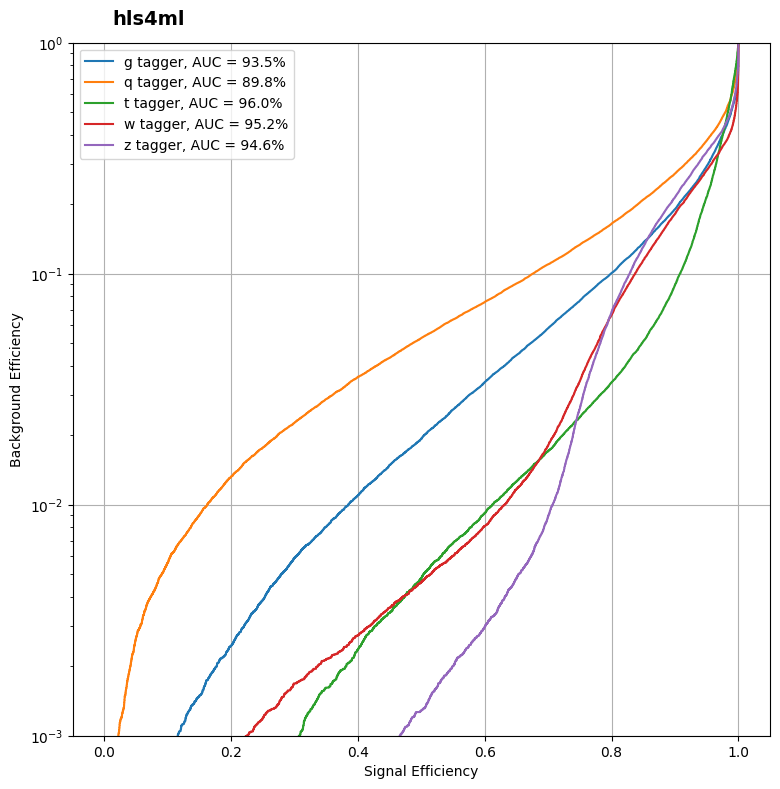

In [10]:
import plotting
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

y_keras = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, le.classes_)

## Convert the model to FPGA firmware with hls4ml
Now we will go through the steps to convert the model we trained to a low-latency optimized FPGA firmware with hls4ml.
First, we will evaluate its classification performance to make sure we haven't lost accuracy using the fixed-point data types. 
Then we will synthesize the model with Vitis HLS and check the metrics of latency and FPGA resource usage.

### Make an hls4ml config & model
The hls4ml Neural Network inference library is controlled through a configuration dictionary.
In this example we'll use the most simple variation, later exercises will look at more advanced configuration.

In [16]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='model', backend='Vitis')
print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_1/hls4ml_prj', part='xck26-sfvc784-2LV-c'
)

-----------------------------------
Configuration
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
-----------------------------------


Let's visualise what we created. The model architecture is shown, annotated with the shape and data types

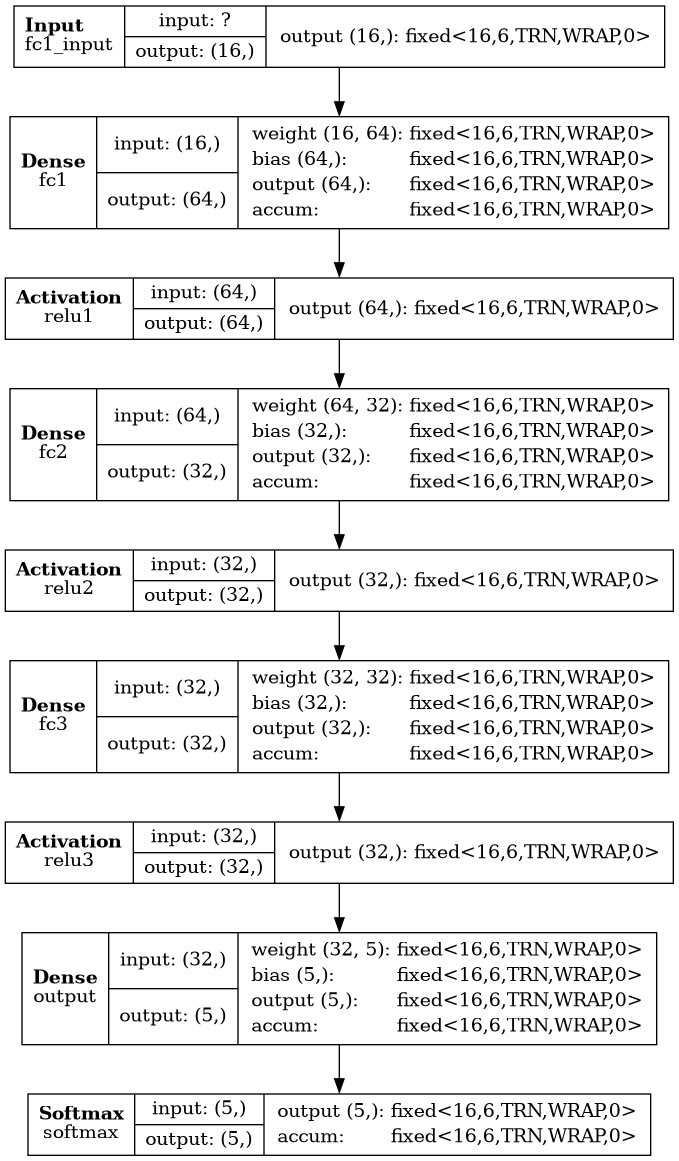

In [17]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## Compile, predict
Now we need to check that this model performance is still good. We compile the hls_model, and then use `hls_model.predict` to execute the FPGA firmware with bit-accurate emulation on the CPU.

In [18]:
hls_model.compile()
X_test = np.ascontiguousarray(X_test)
y_hls = hls_model.predict(X_test)

## Compare
That was easy! Now let's see how the performance compares to Keras:

Keras  Accuracy: 0.7581566265060241
hls4ml Accuracy: 0.7577650602409639


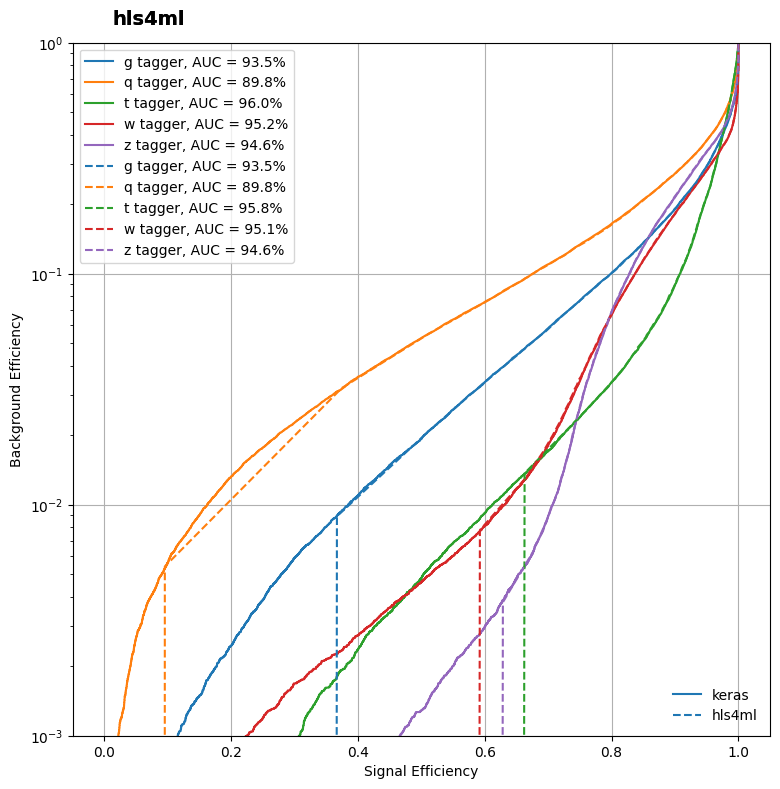

In [19]:
print("Keras  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_keras, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_keras, le.classes_)
plt.gca().set_prop_cycle(None)  # reset the colors
_ = plotting.makeRoc(y_test, y_hls, le.classes_, linestyle='--')

from matplotlib.lines import Line2D

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
from matplotlib.legend import Legend

leg = Legend(ax, lines, labels=['keras', 'hls4ml'], loc='lower right', frameon=False)
ax.add_artist(leg)

## Synthesize
Now we'll actually use Vitis HLS to synthesize the model. We can run the build using a method of our `hls_model` object.
After running this step, we can integrate the generated IP into a workflow to compile for a specific FPGA board.
In this case, we'll just review the reports that Vitis HLS generates, checking the latency and resource usage.

**This can take several minutes.**

While the C-Synthesis is running, we can monitor the progress looking at the log file by opening a terminal from the notebook home, and executing:

`tail -f model_1/hls4ml_prj/vitis_hls.log`

In [21]:
hls_model.build(csim=False)


****** vitis-run v2025.2 (64-bit)
  **** SW Build 6295257 on 2025-11-13-01:29:13
  **** Start of session at: Mon Mar 16 16:21:10 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.2 6295257
Sourcing Tcl script '/home/ubuntu/work/hls4ml-tutorial/model_1/hls4ml_prj/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
Resolution: For help on HLS 200-2182 see docs.amd.com/access/sources/dita/topic?Doc_Version=2025.2%20English&url=ug1448-hls-guidance&resourceid=200-2182.html
INFO: [HLS 200-10] Opening solution '/home/ubuntu/work/hls4ml-tutorial/model_1/hls4ml_prj/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -

INFO: [HLS 200-1995] There were 16,116 instructions in the design after the 'Performance (step 1)' phase of compilation. See the Design Size Report for more details (/home/ubuntu/work/hls4ml-tutorial/model_1/hls4ml_prj/myproject_prj/solution1/syn/report/csynth_design_size.rpt:2)
INFO: [HLS 200-1995] There were 15,920 instructions in the design after the 'Performance (step 2)' phase of compilation. See the Design Size Report for more details (/home/ubuntu/work/hls4ml-tutorial/model_1/hls4ml_prj/myproject_prj/solution1/syn/report/csynth_design_size.rpt:2)
INFO: [HLS 200-1995] There were 15,726 instructions in the design after the 'Performance (step 3)' phase of compilation. See the Design Size Report for more details (/home/ubuntu/work/hls4ml-tutorial/model_1/hls4ml_prj/myproject_prj/solution1/syn/report/csynth_design_size.rpt:2)
INFO: [HLS 200-1995] There were 15,726 instructions in the design after the 'Performance (step 4)' phase of compilation. See the Design Size Report for more det

INFO: [HLS 200-111] Finished Standard Transforms: CPU user time: 0.38 seconds. CPU system time: 0.08 seconds. Elapsed time: 0.48 seconds; current allocated memory: 348.496 MB.
INFO: [HLS 200-10] Checking synthesizability ...
INFO: [HLS 200-111] Finished Checking Synthesizability: CPU user time: 0.76 seconds. CPU system time: 0.03 seconds. Elapsed time: 0.78 seconds; current allocated memory: 356.113 MB.
INFO: [XFORM 203-11] Balancing expressions in function 'nnet::softmax_stable<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, softmax_config13>' (firmware/nnet_utils/nnet_activation.h:51:1)...4 expression(s) balanced.
INFO: [XFORM 203-11] Balancing expressions in function 'nnet::dense_latency<ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, ap_fixed<16, 6, (ap_q_mode)5, (ap_o_mode)3, 0>, config8>' (firmware/nnet_utils/nnet_dense_latency.h:26:27)...926 expression(s) balanced.
INFO: [XFORM 203-11] Balancing expressions in function 'nnet::dense

INFO: [SCHED 204-61] Pipelining function 'dense_latency<ap_fixed<16, 6, 5, 3, 0>, ap_fixed<16, 6, 5, 3, 0>, config8>'.
INFO: [HLS 200-1470] Pipelining result : Target II = NA, Final II = 1, Depth = 2, function 'dense_latency<ap_fixed<16, 6, 5, 3, 0>, ap_fixed<16, 6, 5, 3, 0>, config8>'
INFO: [SCHED 204-11] Finished scheduling.
INFO: [HLS 200-111] Finished Scheduling: CPU user time: 2.88 seconds. CPU system time: 0.01 seconds. Elapsed time: 2.89 seconds; current allocated memory: 1.035 GB.
INFO: [BIND 205-100] Starting micro-architecture generation ...
INFO: [BIND 205-101] Performing variable lifetime analysis.
INFO: [BIND 205-101] Exploring resource sharing.
INFO: [BIND 205-101] Binding ...
INFO: [BIND 205-100] Starting global binding ...
INFO: [BIND 205-100] Finished micro-architecture generation.
INFO: [HLS 200-111] Finished Binding: CPU user time: 4.04 seconds. CPU system time: 0.06 seconds. Elapsed time: 4.11 seconds; current allocated memory: 1.067 GB.
INFO: [HLS 200-10] ---------

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-1030] Apply Unified Pipeline Control on module 'dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s' pipeline 'dense_latency<ap_fixed<16, 6, 5, 3, 0>, ap_fixed<16, 6, 5, 3, 0>, config5>' pipeline type 'function pipeline'
INFO: [RTGEN 206-104] Estimated max fanout for 'dense_latency_ap_fixed_16_6_5_3_0_ap_fixed_16_6_5_3_0_config5_s' is 36566 from HDL expression: ((1'b0 == ap_block_pp0_stage0) & (ap_enable_reg_pp0_iter0 == 1'b1) & (1'b1 == ap_CS_fsm_pp0_stage0))
INFO: [RTGEN 206-100] Generating core module 'mul_16s_10ns_26_1_1': 60 instance(s).
INFO: [RTGEN 206-100] Generating core module 'mul_16s_10s_26_1_1': 53 instance(s).
INFO: [RTGEN 206-100] Generating core module 'mul_16s_11ns

INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [HLS 200-10] -- Generating RTL for module 'myproject' 
INFO: [HLS 200-10] ----------------------------------------------------------------
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/fc1_input' to 'ap_vld'.
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/layer13_out_0' to 'ap_vld'.
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/layer13_out_1' to 'ap_vld'.
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/layer13_out_2' to 'ap_vld'.
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/layer13_out_3' to 'ap_vld'.
INFO: [RTGEN 206-500] Setting interface mode on port 'myproject/layer13_out_4' to 'ap_vld'.
INFO: [RTGEN 206-500] Setting interface mode on function 'myproject' to 'ap_ctrl_hs'.
INFO: [HLS 200-1030] Apply Unified Pipeline Control on module 'myproject' pipeline 'myproject' pipeline type 'function pipeline'
INFO: [R

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.621',
  'BestLatency': '17',
  'WorstLatency': '17',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '4',
  'DSP': '2243',
  'FF': '36608',
  'LUT': '120222',
  'URAM': '0',
  'AvailableBRAM_18K': '288',
  'AvailableDSP': '1248',
  'AvailableFF': '234240',
  'AvailableLUT': '117120',
  'AvailableURAM': '64'}}

## Check the reports
Print out the reports generated by Vitis HLS. Pay attention to the Latency and the 'Utilization Estimates' sections

In [22]:
hls4ml.report.read_vivado_report('model_1/hls4ml_prj/')

Found 1 solution(s) in model_1/hls4ml_prj//myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Mon Mar 16 16:23:44 2026

* Version:        2025.2 (Build 6295257 on Nov 14 2025)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: zynquplus
* Target device:  xck26-sfvc784-2LV-c


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.621 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max    | min | max |   Type  |
    +---------+---------+---

## Exercise
Since `ReuseFactor = 1` we expect each multiplication used in the inference of our neural network to use 1 DSP. Is this what we see? (Note that the Softmax layer should use 5 DSPs, or 1 per class)
Calculate how many multiplications are performed for the inference of this network...
(We'll discuss the outcome)